# UNEC praktikumu: üç nəticəni yoxlamaq

Bu notebook saxlanmış nəticələri real girişlərlə tutuşdurur, SQLite sorğusunu və null simulyasiyasını yenidən hesablayır. SVM training-i burada yenidən işə salınmır; onun tam icrası üçün repo kökündə `python scripts/run_expression_ml.py` işlədin. Dataset: ISLP Khan, 63 train/20 test. Şiş sinfinin təsnifatı erkən diaqnostika sübutu deyil.

Mənbələr: `resources/unec/catalog.csv`, `datasets/public-datasets/khan.md`, `docs/unec/handbook.md`. U4084 database, U4236 statistika, U4252 gen ifadəsi mövzularını verir.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from biolab.statistics import benjamini_hochberg
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'pyproject.toml').exists())
RESULTS = ROOT/'results/expanded-projects'
summaries = {name:json.loads((RESULTS/name/'summary.json').read_text()) for name in ['gene-expression-ml','study-database','biostatistics-lab']}
display(pd.DataFrame([{'project':key, 'summary':str(value)[:160]} for key,value in summaries.items()]))

,project,summary
0,gene-expression-ml,"{'dataset': 'Khan et al. (2001), ISLP four-cla..."
1,study-database,"{'samples': 6, 'genes': 124, 'count_records': ..."
2,biostatistics-lab,{'simulation': 'All 1000 null hypotheses are t...


## 1. Gen ifadəsi: saxlanmış test proqnozları
CV model seçimi üçündür. Aşağıda toxunulmamış test hissəsinin saxlanmış proqnozlarından metriklər yenidən hesablanır.

{'test_n': 20, 'accuracy': 0.95, 'balanced_accuracy': 0.9583333333333334}


,sample_id,truth,prediction
14,test_15,2,4


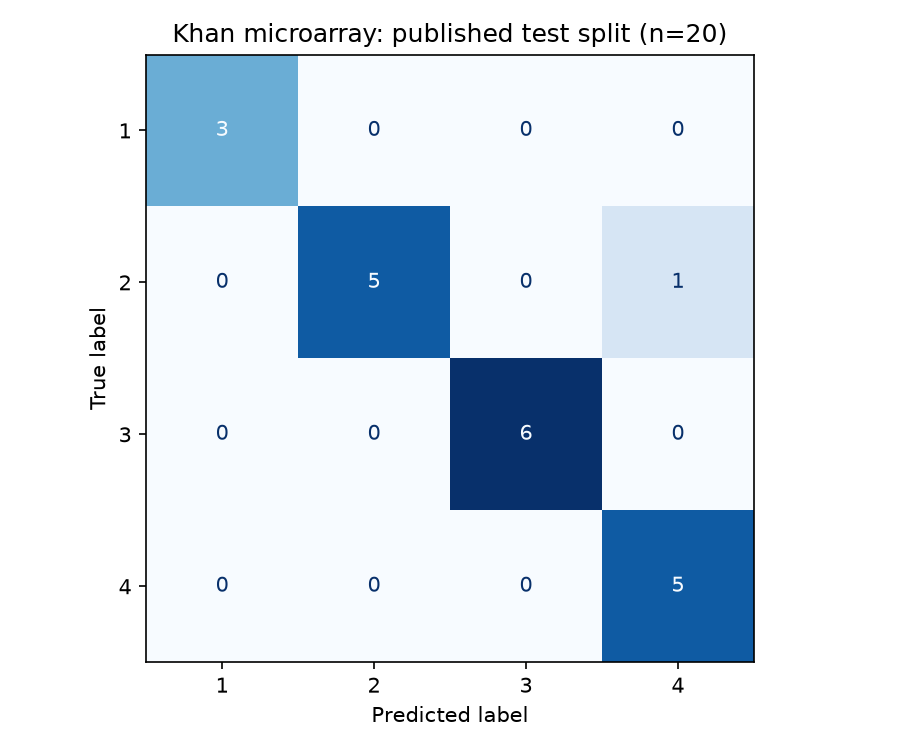

In [2]:
pred = pd.read_csv(RESULTS/'gene-expression-ml/predictions.csv')
accuracy = accuracy_score(pred.truth, pred.prediction)
balanced = balanced_accuracy_score(pred.truth, pred.prediction)
assert len(pred) == 20 and np.isclose(accuracy, .95)
assert np.isclose(balanced, summaries['gene-expression-ml']['test_balanced_accuracy'])
print({'test_n':len(pred), 'accuracy':accuracy, 'balanced_accuracy':balanced})
display(pred.loc[pred.truth != pred.prediction])
display(Image(filename=str(RESULTS/'gene-expression-ml/confusion_matrix.png')))

## 2. Real sayımları SQL ilə toplamaq
Database yalnız oxuma rejimində açılır. Cəmlər ilkin RNA matrisinin hər sütunu ilə ayrı-ayrılıqda yoxlanır.

In [3]:
uri=(RESULTS/'study-database/laboratory.sqlite').as_uri()+'?mode=ro'
with sqlite3.connect(uri, uri=True) as con:
    sql=pd.read_sql_query('SELECT sample_id, SUM(count) AS total FROM gene_count GROUP BY sample_id ORDER BY sample_id', con)
    assert con.execute('PRAGMA integrity_check').fetchone()[0] == 'ok'
    assert con.execute('SELECT COUNT(*) FROM gene_count').fetchone()[0] == 744
counts=pd.read_csv(ROOT/'results/raw-examples/rna-model/counts.tsv',sep='\t',index_col=0)
expected=counts.sum().sort_index()
assert sql.sample_id.tolist() == expected.index.tolist()
np.testing.assert_array_equal(sql.total, expected.to_numpy())
display(sql)

,sample_id,total
0,SRR6357073,38989
1,SRR6357074,39241
2,SRR6357075,39727
3,SRR6357076,40069
4,SRR6357077,39847
5,SRR6357078,39824


## 3. Null simulyasiyasını təkrarlamaq
Bütün 1000 hipotez quruluş etibarilə doğrudur. Bu sintetik data-dır; real gen kəşfi yoxdur.

{'nominal': 47, 'BH': 0}


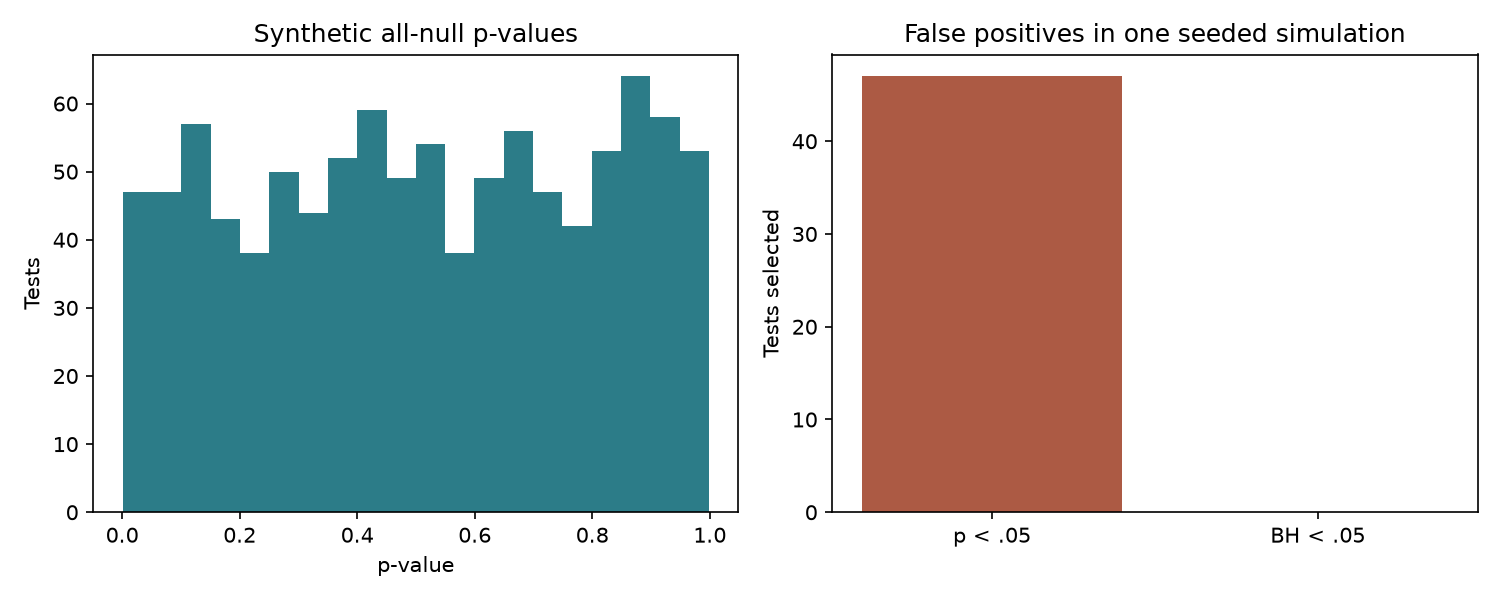

In [4]:
rng=np.random.default_rng(20260916)
a=rng.normal(size=(20,1000)); b=rng.normal(size=(20,1000))
p=ttest_ind(a,b,axis=0,equal_var=False).pvalue
q=benjamini_hochberg(p)
saved=pd.read_csv(RESULTS/'biostatistics-lab/null_tests.csv')
np.testing.assert_allclose(p,saved.p,rtol=1e-10,atol=1e-14)
np.testing.assert_allclose(q,saved.padj_bh,rtol=1e-10,atol=1e-14)
print({'nominal':int((p<.05).sum()),'BH':int((q<.05).sum())})
display(Image(filename=str(RESULTS/'biostatistics-lab/multiple_testing.png')))

## Nəticəni şərh edin

- 19/20 təsnifat bu kiçik tarixi test dəstinə aiddir. Müstəqil cohort və klinik validasiya yoxdur.
- 744 ölçmə 124 gen × 6 nümunədir; SQL query gen ifadəsi fərqini test etmir.
- 47 nominal yanlış müsbət çoxsaylı test problemini göstərir. BH-də sıfır seçimin bütün realizasiyalarda təkrarlanması gözlənilmir.
- Tapşırıq: balanced accuracy-ni sinif recall-larından hesablayın; missing count ilə zero count üçün ayrı data qaydası təklif edin.